## Set parameters

Processing: melan_highgrade_case64_match1.tif
Processing: sox10_highgrade_case65_match2.tif
Processing: sox10_highgrade_case68_match1.tif
Processing: melan_highgrade_case64_match2.tif
Processing: sox10_highgrade_case68_match3.tif
Processing: h&e_highgrade_case64_match4.tif
Processing: sox10_highgrade_case68_match2.tif
Processing: melan_highgrade_case64_match3.tif
Processing: h&e_highgrade_case64_match1.tif
Processing: melan_highgrade_case64_match4.tif
Processing: h&e_highgrade_case64_match3.tif
Processing: h&e_highgrade_case64_match2.tif
Processing: melan_highgrade_case66_match1.tif
Processing: h&e_highgrade_case66_match4.tif
Processing: sox10_highgrade_case67_match1.tif
Processing: melan_highgrade_case66_match3.tif
Processing: h&e_highgrade_case63_match1.tif
Processing: melan_highgrade_case66_match2.tif
Processing: h&e_highgrade_case66_match1.tif
Processing: h&e_highgrade_case66_match2.tif
Processing: melan_highgrade_case66_match4.tif
Processing: melan_highgrade_case63_match1.tif
Proc

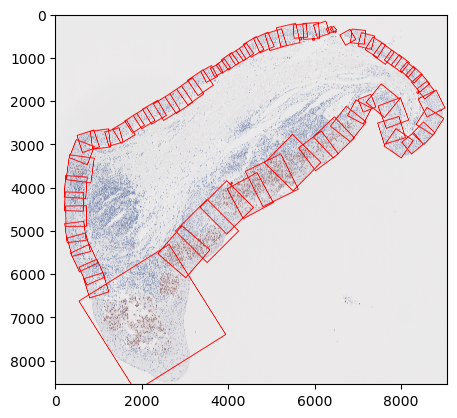

In [26]:
import os
import numpy as np
import cv2
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import pandas as pd
import csv
from PIL import Image

# Processing Parameters
smoothing_size = 70
extension_factor = 1.1
step_size = 2
max_width = 2048
overlap_threshold = 0.3
weight_epithelium_coverage = 0.8
weight_background_pixels = 0.2

# Directories
input_folder = "input"
output_folder = "output_new"
os.makedirs(output_folder, exist_ok=True)

# Function to draw patches
def draw_patches(image, patch_list, color=[255, 0, 0], thickness=20):
    patches_on_slice = image.copy()
    for contour_patches in patch_list:
        for patch in contour_patches:
            points = patch.astype(np.int32)
            cv2.polylines(patches_on_slice, [points], isClosed=True, color=color, thickness=thickness)
    return patches_on_slice

# Function to calculate patch overlap
def patch_overlap(square1, square2):
    square1 = Polygon(square1)
    square2 = Polygon(square2)

    if not square1.intersects(square2):
        return 0

    intersection_area = square1.intersection(square2).area
    smallest_area = min(square1.area, square2.area)
    return intersection_area / smallest_area

# looping through each image in input
for file in os.listdir(input_folder):
    if file.lower().endswith('.tif'):
        slice_file = os.path.join(input_folder, file)
        slice_detail = os.path.splitext(file)[0]
        mask_name = f"{slice_detail}.png"
        mask_file = os.path.join(input_folder, mask_name)

        patched_slice_name = os.path.join(output_folder, f"patched_after_improvement_{mask_name}")
        metrics_file_name = os.path.join(output_folder, f"metrics_after_improvement_{slice_detail}.csv")
        patch_length_filename = os.path.join(output_folder, f"patch_lengths_after_improvement_{slice_detail}.csv")

        print(f"Processing: {file}")

        # Reading data
        tissue_slice = cv2.cvtColor(cv2.imread(slice_file), cv2.COLOR_BGR2RGB)
        epithelium_mask = cv2.cvtColor(cv2.imread(mask_file), cv2.COLOR_BGR2RGB)
        epithelium_mask_gray = cv2.cvtColor(epithelium_mask, cv2.COLOR_RGB2GRAY)
        Otsu_threshold, epithelium_mask_2D = cv2.threshold(epithelium_mask_gray, 0, 255, 
                                                            cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

        # Getting contours
        contours, hierarchy = cv2.findContours(epithelium_mask_2D, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # Getting tangents and normals on contour points
        all_normals = []
        all_tangents = []

        for contour in contours:
            contour_points = contour.reshape(-1, 2)
            num_contour_points = len(contour_points)
            tangents = np.zeros_like(contour_points, dtype=float)

            for i in range(num_contour_points):
                prev_idx = (i - smoothing_size) % num_contour_points
                next_idx = (i + smoothing_size) % num_contour_points
                tangent = contour_points[next_idx] - contour_points[prev_idx]
                tangent = tangent / (np.linalg.norm(tangent) + 1e-8)
                tangents[i] = tangent

            normals = np.zeros_like(tangents)
            normals[:, 0] = -tangents[:, 1]
            normals[:, 1] = tangents[:, 0]

            all_normals.append(normals)
            all_tangents.append(tangents)

        all_patches = []
        all_patch_lengths = []
        height, width = epithelium_mask_2D.shape

        # Finding patch corners on each contour
        for c in range(len(contours)):
            contour_points = contours[c].reshape(-1, 2)
            contour_normals = all_normals[c]
            contour_tangents = all_tangents[c]
            contour_patch_lengths = []
            squares = []

            for i, point in enumerate(contour_points):
                point = point.astype(int)
                steps = np.arange(0, max_width, step_size)[:, None]
                normal_points = np.clip(point - steps * contour_normals[i], 0, [width - 1, height - 1]).astype(int)

                pixel_values = epithelium_mask_2D[normal_points[:, 1], normal_points[:, 0]]
                stop = np.where(pixel_values == 0)[0]

                epithelium_width = stop[0] * step_size if stop.size > 0 else max_width

                # Adjust extension_factor if the tissue is big enough
    
                if epithelium_width > max_width / 2:
                    adjusted_extension_factor = 1.2
                else:
                    adjusted_extension_factor = extension_factor
                
                patch_length = int(epithelium_width * adjusted_extension_factor)
                half_patch_length = patch_length // 2

                # Skip tiny patches
                min_patch_length = 20
                if patch_length < min_patch_length:
                    continue


                corners = np.array([
                    point + (contour_tangents[i] * half_patch_length),
                    point - (contour_tangents[i] * half_patch_length),
                    point - (contour_tangents[i] * half_patch_length) - (contour_normals[i] * patch_length),
                    point + (contour_tangents[i] * half_patch_length) - (contour_normals[i] * patch_length)
                ])
                squares.append(corners)
                contour_patch_lengths.append(patch_length)

            all_patches.append(squares)
            all_patch_lengths.append(contour_patch_lengths)

        all_selected_patches = []
        all_selected_patch_lengths = []

        # Removing highly overlapping contours
        for c in range(len(contours)):
            contour_points = contours[c].reshape(-1, 2)
            selected_patches = []
            selected_patch_lengths = []
            for i, point in enumerate(contour_points):
                if not all_patches[c] or i >= len(all_patches[c]):
                    continue
                    
                current_patch = all_patches[c][i]
                current_patch_length = all_patch_lengths[c][i]
                if not any(patch_overlap(current_patch, ith_selected_patch) > overlap_threshold for ith_selected_patch in selected_patches):
                    selected_patches.append(current_patch)
                    selected_patch_lengths.append(current_patch_length)

            all_selected_patches.append(selected_patches)
            all_selected_patch_lengths.append(selected_patch_lengths)

        selected_patches_on_slice = draw_patches(tissue_slice, all_selected_patches)

        # Exporting patched slice
        cv2.imwrite(patched_slice_name, cv2.cvtColor(selected_patches_on_slice, cv2.COLOR_RGB2BGR))

        # Calculating performance metrics
        total_epithelium_pixels = (epithelium_mask_2D > 0).sum()
        patch_mask = np.zeros_like(epithelium_mask_2D, dtype=np.uint8)

        for contour_patches in all_selected_patches:
            for patch in contour_patches:
                patch = np.array(patch, dtype=np.int32).reshape(-1, 1, 2)
                cv2.fillPoly(patch_mask, [patch], 255)

        number_of_patch_mask_pixels = np.count_nonzero(patch_mask > 0)
        covered_epithelium_pixels = np.count_nonzero((patch_mask > 0) & (epithelium_mask_2D > 0))
        covered_background_pixels = np.count_nonzero((patch_mask > 0) & (epithelium_mask_2D == 0))

        total_epithelium_coverage = (covered_epithelium_pixels / total_epithelium_pixels * 100)
        background_pixel_percent = (covered_background_pixels / number_of_patch_mask_pixels * 100)
        score = weight_epithelium_coverage * total_epithelium_coverage + weight_background_pixels * (100 - background_pixel_percent)

        # Exporting performance metrics
        metrics = pd.DataFrame({'Metric':['total_epithelium_coverage', 'background_pixel_percent',
                       'score', 'smoothing_size', 'extension_factor', 'step_size',
                       'max_width', 'overlap_threshold'], 
              'Value':[total_epithelium_coverage, background_pixel_percent, score, 
                      smoothing_size, extension_factor, step_size, max_width, overlap_threshold]})

        metrics.to_csv(metrics_file_name, index=False)


        # Exporting patch lengths
        max_length = max(len(contour_patch_lengths) for contour_patch_lengths in all_selected_patch_lengths)

        padded_list = [contour_patch_lengths + [''] * (max_length - len(contour_patch_lengths)) \
                       for contour_patch_lengths in all_selected_patch_lengths]

        transposed_list = list(map(list, zip(*padded_list)))

        with open(patch_length_filename, mode='w', newline='') as file:
            writer = csv.writer(file)
            writer.writerows(transposed_list)

        plt.imshow(selected_patches_on_slice);


In [28]:
print(f"Total Coverage: {total_epithelium_coverage:.2f}%")
print(f"Background Pixel Percentage: {background_pixel_percent:.2f}%")
print(f"Score Percentage: {score:.2f}%")

Total Coverage: 97.28%
Background Pixel Percentage: 18.36%
Score Percentage: 94.15%
